# SOM Customer Segmentation

Real-world use case: segment customers by purchasing behavior.
We'll use the Mall Customers dataset — a classic retail segmentation problem.

**Goal**: Group customers by Age, Income, and Spending Score
so a business can target each segment differently.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import MinMaxScaler
from kohonen.som import SOM

## Load Dataset
Mall Customers dataset: 200 customers with Age, Annual Income, Spending Score.

In [2]:
# Download dataset
import urllib.request

url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv"
urllib.request.urlretrieve(url, "../data/mall_customers.csv")

df = pd.read_csv("../data/mall_customers.csv")
print(df.shape)
df.head()

(200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print(df.dtypes)
print("\nMissing values:", df.isnull().sum().sum())
print("\nStats:")
df.describe()

CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing values: 0

Stats:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Prepare Features
We use Age, Annual Income, and Spending Score.
Gender is encoded as 0/1.

In [4]:
df['Gender_encoded'] = (df['Genre'] == 'Male').astype(int)

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_encoded']
X = df[features].values

print(f"Feature matrix shape: {X.shape}")
print(f"Features used: {features}")

Feature matrix shape: (200, 4)
Features used: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_encoded']


## Train the SOM
Grid size suggestion based on 200 customers.

In [5]:
som = SOM(grid_x=10, grid_y=10, learning_rate=0.5, sigma=1.5)
som.suggest_grid_size(len(X))
som.fit(X, epochs=2000)

Suggested grid size for 200 samples: 9x9 (81 neurons)
Training SOM (10x10) for 2000 epochs...
Done. Quantization Error: 0.0864 | Topographic Error: 0.0350


## U-Matrix
Reveals natural cluster boundaries in the customer data.

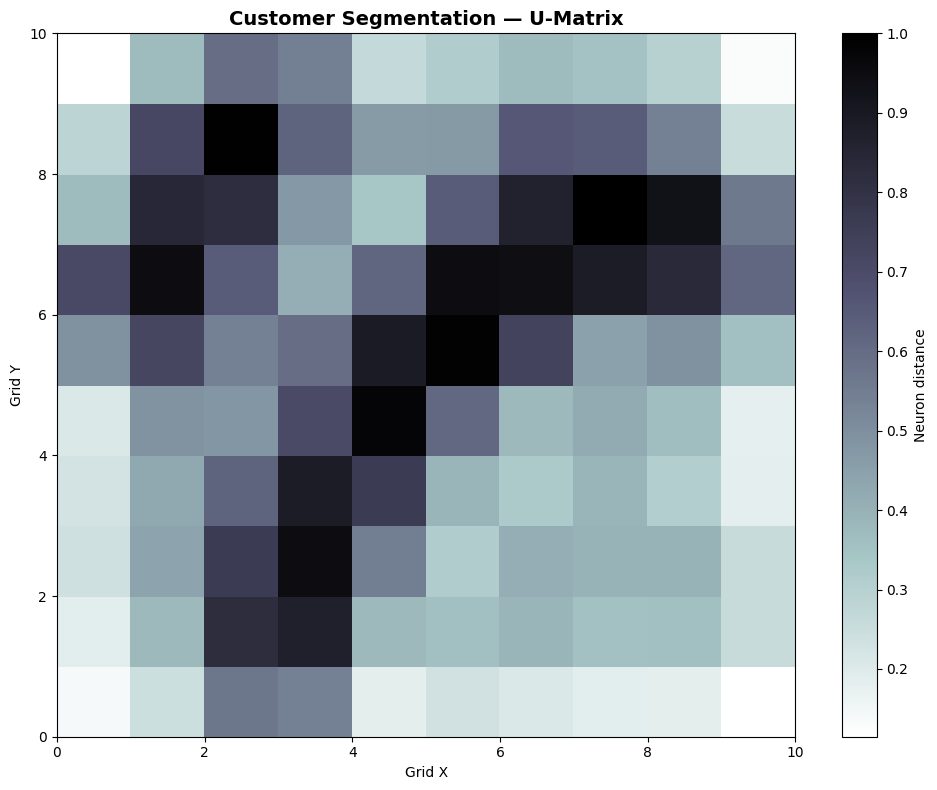

In [6]:
som.plot_umatrix(title="Customer Segmentation — U-Matrix")

## Segment Customers
Assign each customer to a SOM neuron, then group neurons into segments.

In [7]:
# Get BMU for each customer
X_scaled = MinMaxScaler().fit_transform(X)
bmu_list = [som.som.winner(x) for x in X_scaled]

df['BMU_x'] = [b[0] for b in bmu_list]
df['BMU_y'] = [b[1] for b in bmu_list]
df['Segment'] = [b[0] * 10 + b[1] for b in bmu_list]

print(f"Unique neurons activated: {df['Segment'].nunique()}")
df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Segment']].head(10)

Unique neurons activated: 72


,Age,Annual Income (k$),Spending Score (1-100),Segment
0,19,15,39,14
1,21,15,81,24
2,20,16,6,65
3,23,16,77,40
4,31,17,40,54
5,22,17,76,40
6,35,18,6,65
7,23,18,94,30
8,64,19,3,39
9,30,19,72,40


## Visualize Segments on Map
Each dot = one customer plotted at their BMU position.
Color = spending score (low=blue, high=red).

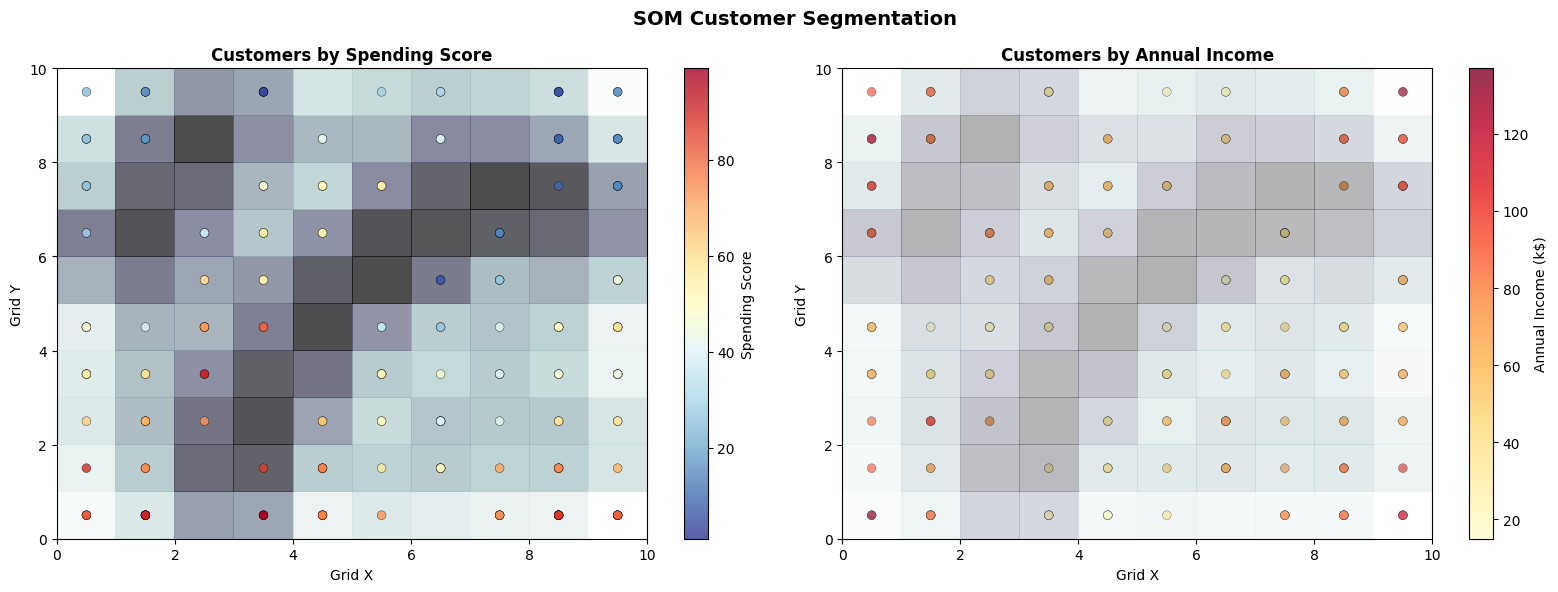

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: color by spending score
umatrix = som.som.distance_map()
axes[0].pcolor(umatrix.T, cmap='bone_r', alpha=0.7)

scatter = axes[0].scatter(
    df['BMU_x'] + 0.5,
    df['BMU_y'] + 0.5,
    c=df['Spending Score (1-100)'],
    cmap='RdYlBu_r',
    s=40, alpha=0.8, edgecolors='black', linewidths=0.3
)
plt.colorbar(scatter, ax=axes[0], label='Spending Score')
axes[0].set_title('Customers by Spending Score', fontweight='bold')
axes[0].set_xlabel('Grid X')
axes[0].set_ylabel('Grid Y')

# Right: color by annual income
scatter2 = axes[1].scatter(
    df['BMU_x'] + 0.5,
    df['BMU_y'] + 0.5,
    c=df['Annual Income (k$)'],
    cmap='YlOrRd',
    s=40, alpha=0.8, edgecolors='black', linewidths=0.3
)
axes[1].pcolor(umatrix.T, cmap='bone_r', alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Annual Income (k$)')
axes[1].set_title('Customers by Annual Income', fontweight='bold')
axes[1].set_xlabel('Grid X')
axes[1].set_ylabel('Grid Y')

plt.suptitle('SOM Customer Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Component Planes
Which features drive the clustering?

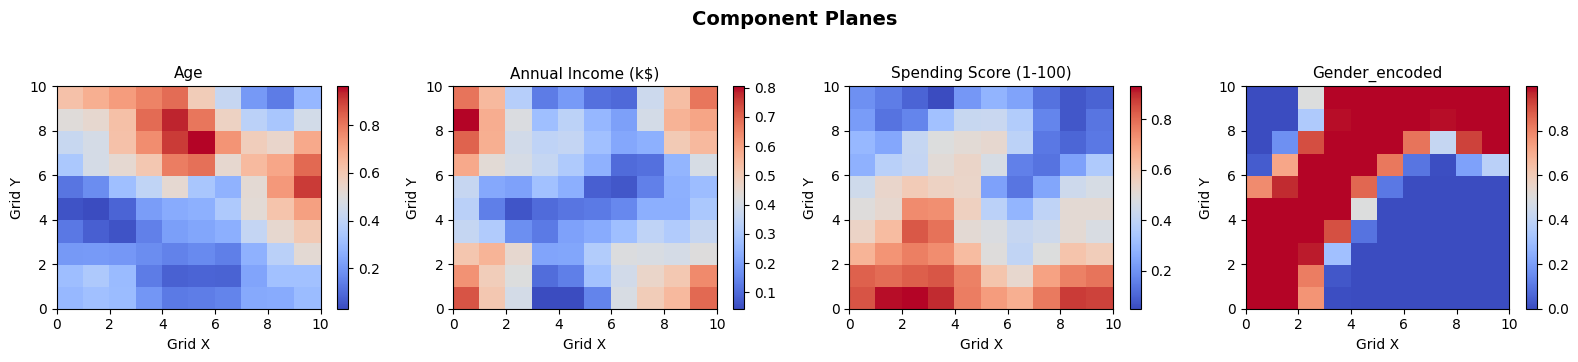

In [9]:
som.plot_component_planes(feature_names=features)

## Segment Profiles
Summarize each cluster — what does each customer group look like?

In [10]:
# Group customers into broad segments using BMU quadrants
def assign_quadrant(row):
    x, y = row['BMU_x'], row['BMU_y']
    if x < 5 and y < 5:
        return 'Low Income / Low Spend'
    elif x >= 5 and y < 5:
        return 'High Income / Low Spend'
    elif x < 5 and y >= 5:
        return 'Low Income / High Spend'
    else:
        return 'High Income / High Spend'

df['Segment_Label'] = df.apply(assign_quadrant, axis=1)

profile = df.groupby('Segment_Label')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].agg(['mean', 'count'])

print("Customer Segment Profiles:")
print(profile.round(1))

Customer Segment Profiles:
                           Age       Annual Income (k$)        \
                          mean count               mean count   
Segment_Label                                                   
High Income / High Spend  46.9    41               58.6    41   
High Income / Low Spend   35.8    69               63.1    69   
Low Income / High Spend   50.5    40               66.6    40   
Low Income / Low Spend    27.1    50               53.9    50   

                         Spending Score (1-100)        
                                           mean count  
Segment_Label                                          
High Income / High Spend                   23.0    41  
High Income / Low Spend                    57.9    69  
Low Income / High Spend                    34.5    40  
Low Income / Low Spend                     74.5    50  


## Business Interpretation

| Segment | Strategy |
|---|---|
| High Income / High Spend | VIP loyalty program, premium offers |
| High Income / Low Spend | Re-engagement campaigns, understand friction |
| Low Income / High Spend | Budget deals, installment payment options |
| Low Income / Low Spend | Mass market promotions, price sensitivity |

SOMs reveal these segments **without any labels** — purely from behavioral patterns.